In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import numpy as np
import random
import os

def set_seed(seed):
    random.seed(seed)
    np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Ensure that CUDA operations are deterministic if using GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
        # # slower but more reproducibility
        # torch.backends.cudnn.benchmark = False
set_seed(42)

In [3]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [4]:

run_number = 6
root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.18.0.12150 f0baf65fb3 release-ili-0.18 'Tue Oct 21 19:59:39 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(153): WebSoc

In [6]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [7]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

    # transform = transforms.Compose([
    #     transforms.Lambda(resize_to_224),
    #     transforms.ToTensor(),
    #     transforms.Lambda(lambda x: x.expand(3, -1, -1)),
    #     transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    # ])

    # wrapped_model = PreprocessingModel(model, transform)
    #return wrapped_model

In [8]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_v1_23_6.pth")
#model,weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_v1_3_16.pth")

transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

In [9]:
def gen_image(img_start, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=22,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img

In [10]:
patch_length = 0.3
stride = 0.15
ranges = [(start, start + patch_length) for start in np.arange(start_dist, end_dist - patch_length + stride, stride)]

In [11]:
# patch_length = 0.3
# stride = 0.15
# ranges = [(start, start + patch_length) for start in np.arange(start_dist, end_dist - patch_length + stride, stride)]
# img_std_dir = os.path.join(root_dir, "img_std_stride15")
# img_patch_dir = os.path.join(root_dir, "img_patch_stride15")
# os.makedirs(img_std_dir, exist_ok=True)
# os.makedirs(img_patch_dir, exist_ok=True)
# for i, (img_start, img_end) in enumerate(ranges):
#         if i % 200 == 0:
#             print(f"Processing image {i}/{len(ranges)}")
#         vd = (img_start + img_end) / 2 #147828.385 -0.15#
#         img_std = gen_image(vd, show_im=False, normalize="std")
#         img_patch = gen_image(vd, show_im=False, normalize="patch")
#         np.save(os.path.join(img_std_dir, f"img_std_{vd*1000:.0f}.npy"), img_std)
#         np.save(os.path.join(img_patch_dir, f"img_patch_{vd*1000:.0f}.npy"), img_patch)

In [12]:
len(ranges)

7640

In [13]:
# Multi-label inference: collect per-sample probability vectors & binary predictions

img_std_dir = os.path.join(root_dir, "img_std_stride15")
img_patch_dir = os.path.join(root_dir, "img_patch_stride15")
batch_size = 64
threshold = 0.99  # per-class decision threshold

all_probs = []           # list of np.array shape (C,)
all_preds = []           # list of np.array shape (C,) (0/1)
all_vds   = []           # view-distance centers
preds_list = {}          # vd -> list of positive class indices (above hi_thresh)
hi_thresh = 0.99          # optional high-confidence filter

model.eval()
model.to(device)

with torch.no_grad():
    for batch_start in range(0, len(ranges), batch_size):
        print(f"Processing batch {batch_start // batch_size + 1}")
        batch_ranges = ranges[batch_start:batch_start + batch_size]

        imgs = []
        vds  = []
        for img_start, img_end in batch_ranges:
            vd = (img_start + img_end) / 2
            vds.append(vd)
            img_std = np.load(os.path.join(img_std_dir, f"img_std_{vd*1000:.0f}.npy"))[:20, :]
            img_patch = np.load(os.path.join(img_patch_dir, f"img_patch_{vd*1000:.0f}.npy"))[:20, :]
            img_patch = np.nan_to_num(img_patch, nan=0.0, posinf=0.0, neginf=0.0)

            # Trend channel
            trend = seasonal_decompose(
                img_patch.T, model='additive', period=30, extrapolate_trend=2
            ).trend.T

            img = np.stack((img_patch, trend, img_std), axis=0)   # (3,H,W)
            img = transform(img)                                  # tensor (3,224,224) after your transform
            imgs.append(img)

        imgs = torch.stack(imgs, dim=0).to(device)                # (B,3,H,W)
        logits = model(imgs)                                      # (B,C)
        probs = torch.sigmoid(logits).cpu().numpy()               # (B,C)
        preds = (probs >= threshold).astype(np.uint8)             # (B,C)

        for vd, prob_vec, pred_vec in zip(vds, probs, preds):
            all_vds.append(vd)
            all_probs.append(prob_vec)
            all_preds.append(pred_vec)

            # Store high-confidence positive class indices
            pos_hi = np.where(prob_vec >= hi_thresh)[0]
            if len(pos_hi) > 0:
                preds_list[vd] = pos_hi.tolist()

# Convert to arrays
all_probs_arr = np.vstack(all_probs)      # (N,C)
all_preds_arr = np.vstack(all_preds)      # (N,C)
all_vds_arr   = np.array(all_vds)

Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Processing batch 7
Processing batch 8
Processing batch 9
Processing batch 10
Processing batch 11
Processing batch 12
Processing batch 13
Processing batch 14
Processing batch 15
Processing batch 16
Processing batch 17
Processing batch 18
Processing batch 19
Processing batch 20
Processing batch 21
Processing batch 22
Processing batch 23
Processing batch 24
Processing batch 25
Processing batch 26
Processing batch 27
Processing batch 28
Processing batch 29
Processing batch 30
Processing batch 31
Processing batch 32
Processing batch 33
Processing batch 34
Processing batch 35
Processing batch 36
Processing batch 37
Processing batch 38
Processing batch 39
Processing batch 40
Processing batch 41
Processing batch 42
Processing batch 43
Processing batch 44
Processing batch 45
Processing batch 46
Processing batch 47
Processing batch 48
Processing batch 49
Processing batch 50
Processin

In [14]:
all_probs_arr.shape, all_preds_arr.shape, all_vds_arr.shape

((7640, 20), (7640, 20), (7640,))

In [15]:
#preds = [pred.cpu() for pred in preds]
np.save(os.path.join(root_dir, "preds4.npy"), np.array(preds))
np.save(os.path.join(root_dir, "probs4.npy"), np.array(probs))


In [16]:
len(preds), len(probs)

(24, 24)

In [17]:
# preds = np.load(os.path.join(root_dir, "preds4.npy"))
# probs = np.load(os.path.join(root_dir, "probs4.npy"))

In [18]:
len(preds), len(probs), len (ranges)

(24, 24, 7640)

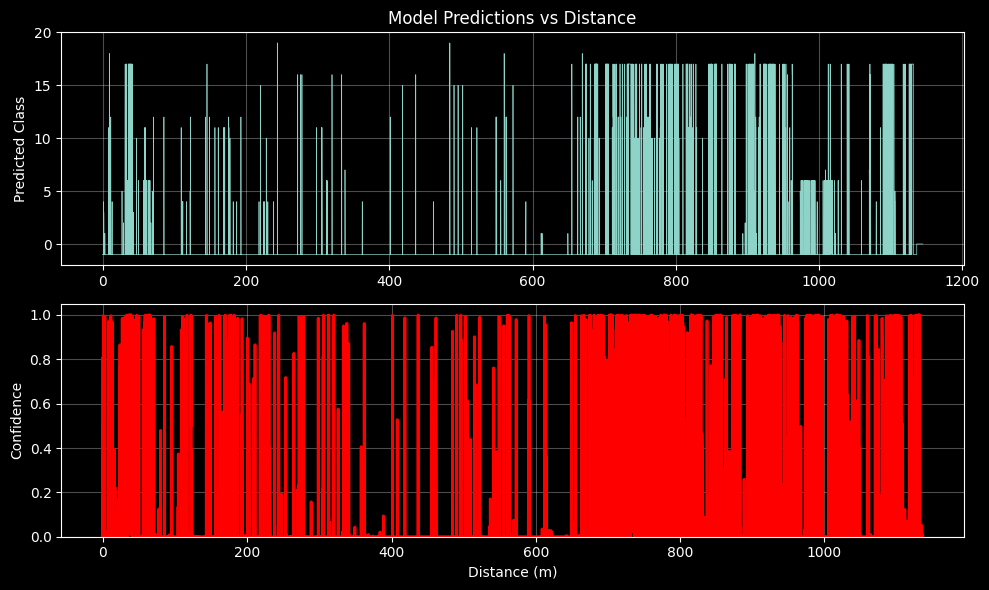

In [19]:
# Plot predictions
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Create x-axis points
patch_length = 0.3
x_points = [(img_start + img_end) / 2 for (img_start, img_end) in ranges]

# Plot class predictions (0 or 1)
plt.subplot(2, 1, 1)
argmax_probs = all_probs_arr.argmax(axis=1)
for i in range(len(x_points)):
    if np.all(all_probs_arr[i, :] <= 0.9):
        argmax_probs[i] = -1
  # Indicate no prediction with -1

plt.step(x_points, argmax_probs, where='mid', linewidth=0.5)
plt.ylabel('Predicted Class')
plt.title('Model Predictions vs Distance')
plt.grid(True, alpha=0.3)

# Plot confidence probabilities
plt.subplot(2, 1, 2)
max_probs = all_probs_arr.max(axis=1)
plt.plot(x_points, max_probs, 'r-', linewidth=2)
plt.xlabel('Distance (m)')
plt.ylabel('Confidence')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

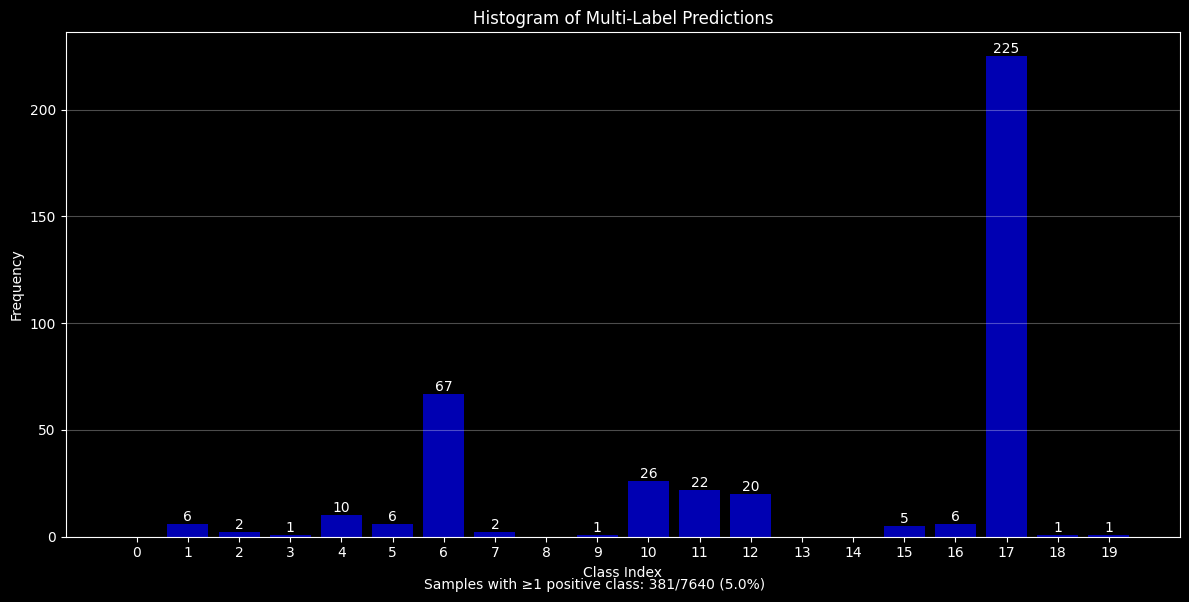

In [20]:
# Multi-label histogram of predictions
plt.figure(figsize=(12, 6))

# Count occurrences of each class (sum along samples dimension)
class_counts = all_preds_arr.sum(axis=0)  # Shape: [num_classes]
num_classes = len(class_counts)

# Create bar chart
bars = plt.bar(range(num_classes), class_counts, alpha=0.7, color='blue')
plt.xticks(range(num_classes))
plt.xlabel('Class Index')
plt.ylabel('Frequency')
plt.title('Histogram of Multi-Label Predictions')

# Add frequency count on top of bars
for i, count in enumerate(class_counts):
    if count > 0:  # Only show non-zero counts
        plt.text(i, count, str(int(count)), ha='center', va='bottom')

# Add percentage of samples with at least one positive prediction
total_samples = all_preds_arr.shape[0]
samples_with_positive = (all_preds_arr.sum(axis=1) > 0).sum()
plt.figtext(0.5, 0.01, 
            f"Samples with ≥1 positive class: {samples_with_positive}/{total_samples} ({samples_with_positive/total_samples:.1%})",
            ha='center', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
def filter_consecutive(indices):
    if not indices:
        return []
    filtered = []
    group = [indices[0]]
    for i in range(1, len(indices)):
        if indices[i] == indices[i-1] + 1:
            group.append(indices[i])
        else:
            # End of a consecutive group
            filtered.append(group[len(group)//2])
            group = [indices[i]]
    # Add the last group
    filtered.append(group[len(group)//2])
    return filtered



389 positive indices found


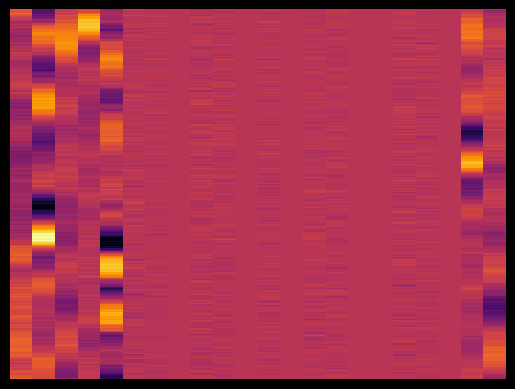

VD: 0.8000000000000004 Prediction: 1 Probability: tensor(0.9972)


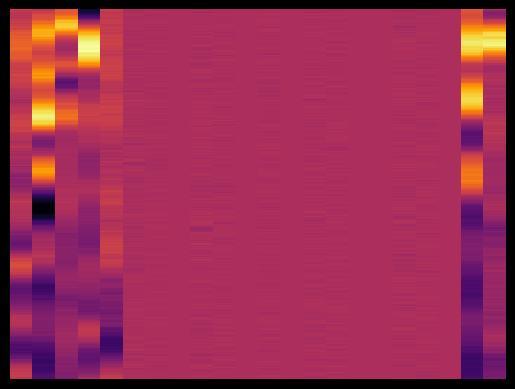

VD: 1.2500000000000004 Prediction: 1 Probability: tensor(0.9949)


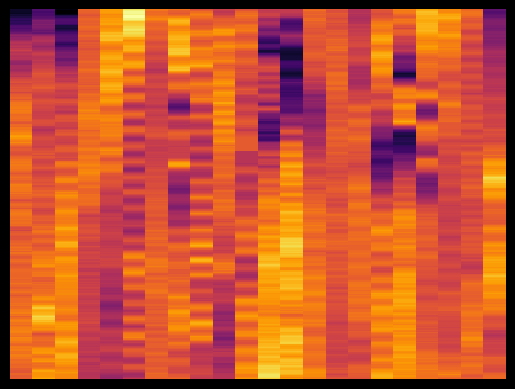

VD: 2.7500000000000004 Prediction: 17 Probability: tensor(0.4951)


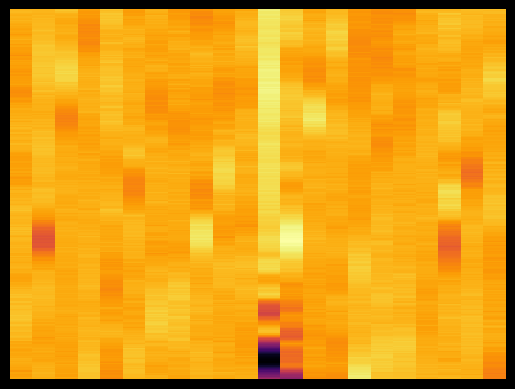

VD: 8.150000000000002 Prediction: 11 Probability: tensor(0.0002)


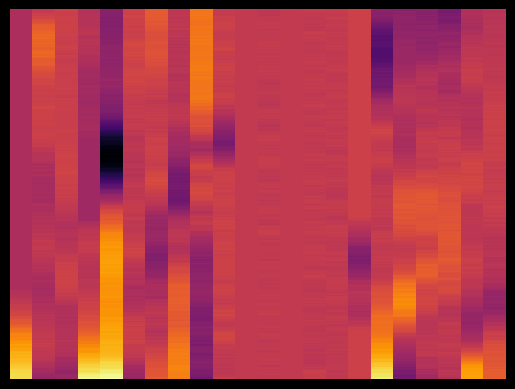

VD: 9.200000000000001 Prediction: 9 Probability: tensor(0.0248)


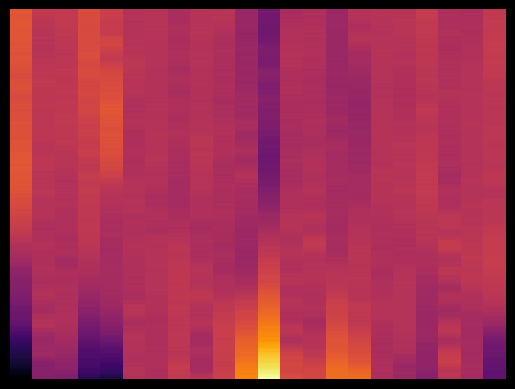

VD: 11.000000000000002 Prediction: 1 Probability: tensor(5.3053e-07)


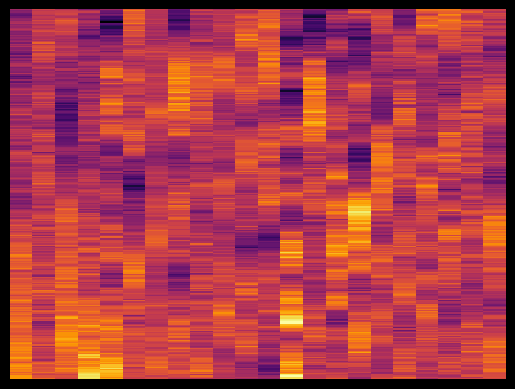

VD: 12.800000000000002 Prediction: 10 Probability: tensor(2.0266e-06)


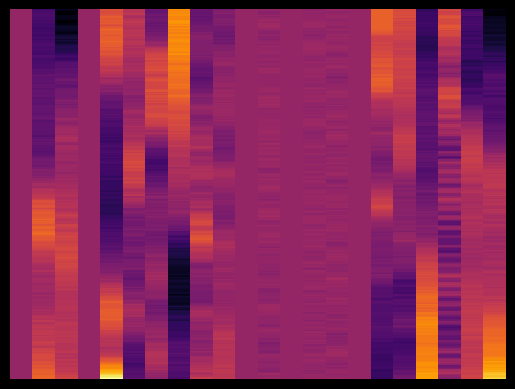

VD: 26.750000000000007 Prediction: 17 Probability: tensor(0.6924)


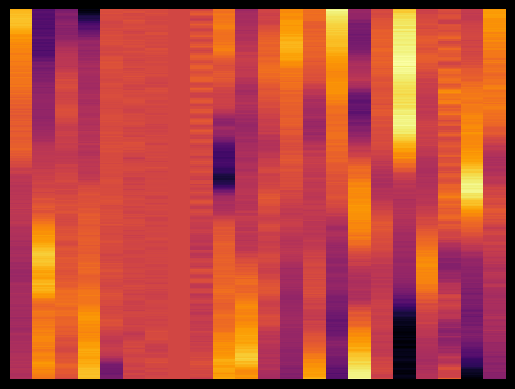

VD: 28.85 Prediction: 9 Probability: tensor(0.7794)


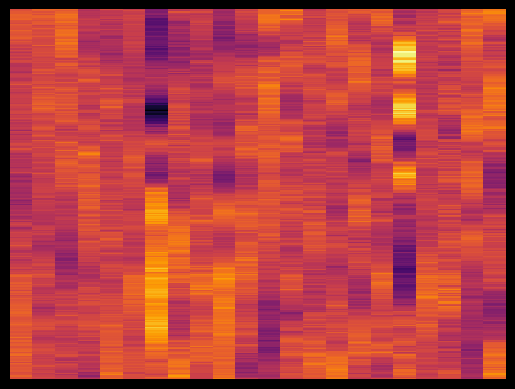

VD: 31.10000000000001 Prediction: 6 Probability: tensor(0.9617)


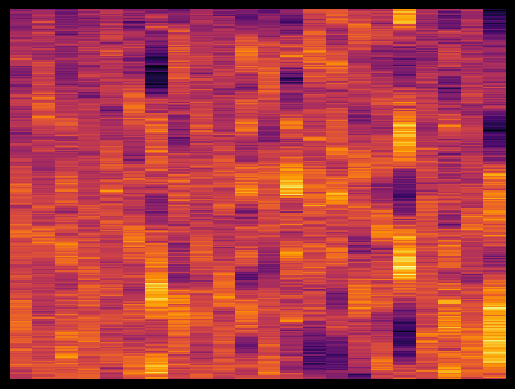

VD: 32.45 Prediction: 17 Probability: tensor(0.0106)


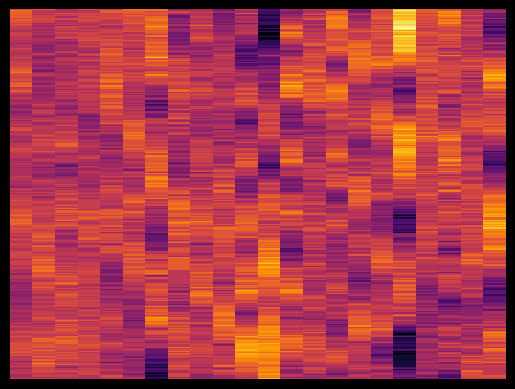

VD: 32.900000000000006 Prediction: 17 Probability: tensor(0.2491)


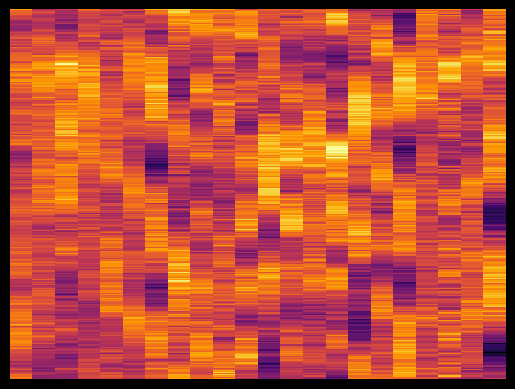

VD: 33.800000000000004 Prediction: 6 Probability: tensor(0.1531)


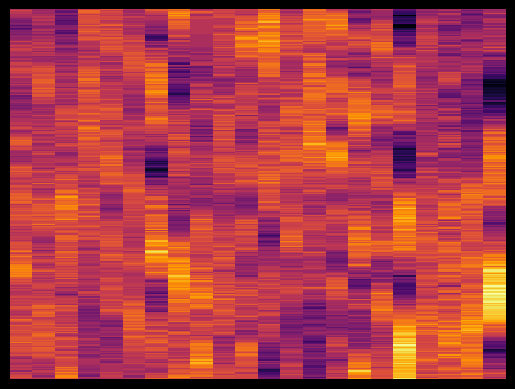

VD: 34.550000000000004 Prediction: 6 Probability: tensor(0.2163)


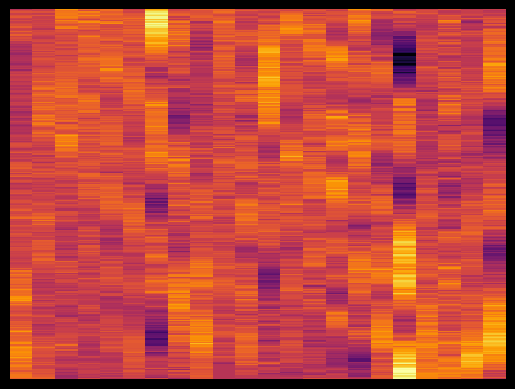

VD: 35.75000000000001 Prediction: 17 Probability: tensor(0.8754)


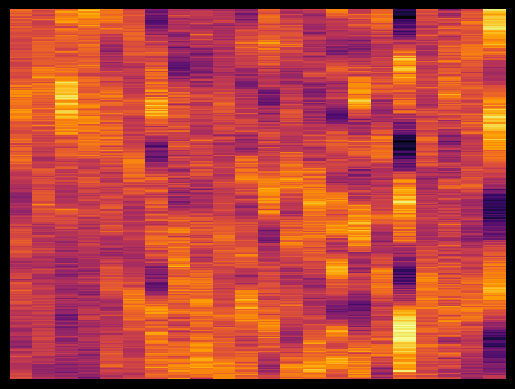

VD: 36.35 Prediction: 17 Probability: tensor(0.9118)


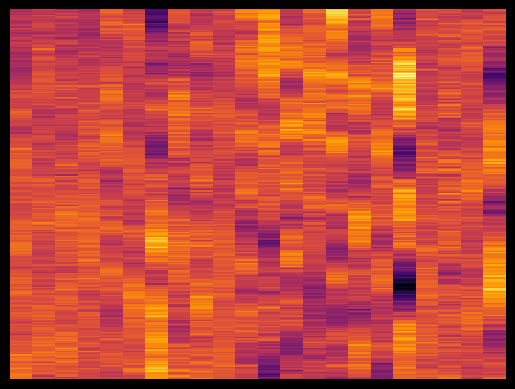

VD: 37.1 Prediction: 17 Probability: tensor(0.9996)


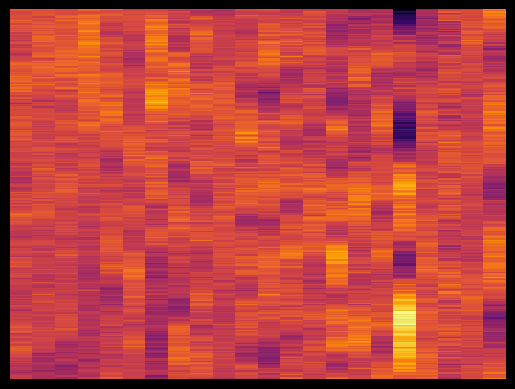

VD: 38.150000000000006 Prediction: 17 Probability: tensor(0.0038)


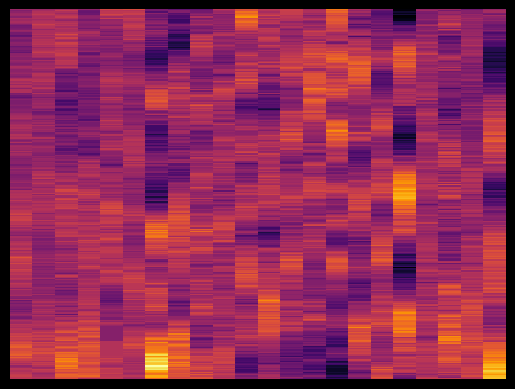

VD: 38.900000000000006 Prediction: 17 Probability: tensor(0.7433)


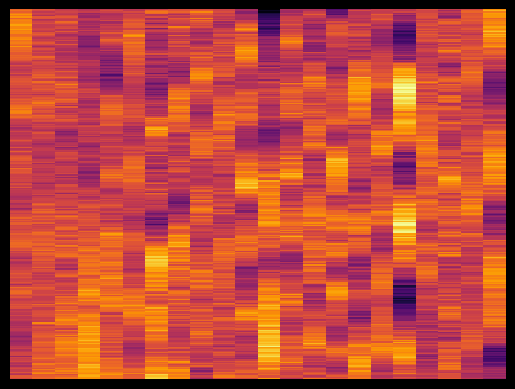

DbHealthCheck.cpp(146): Database service health check complete: Healthy
VD: 39.35 Prediction: 17 Probability: tensor(0.9993)


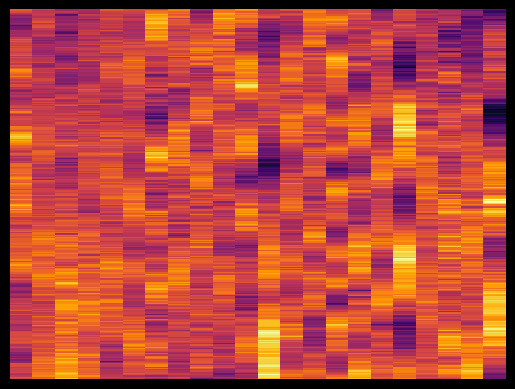

VD: 39.800000000000004 Prediction: 11 Probability: tensor(0.3198)


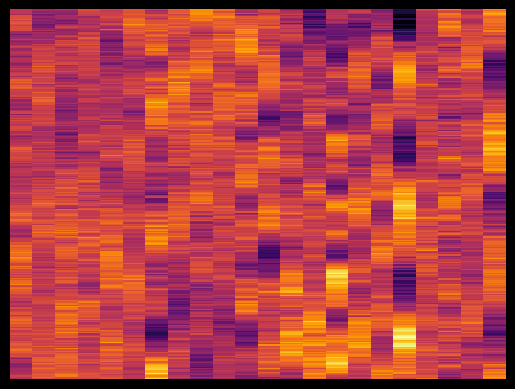

VD: 40.400000000000006 Prediction: 17 Probability: tensor(0.2400)


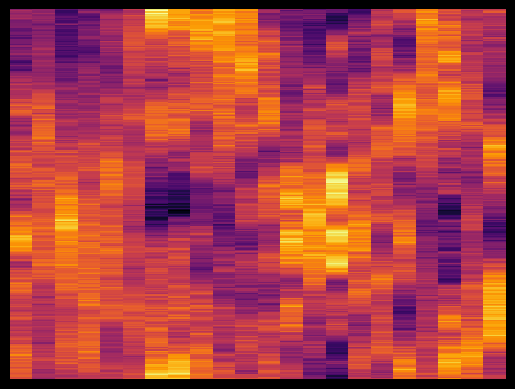

VD: 40.85 Prediction: 6 Probability: tensor(0.9973)


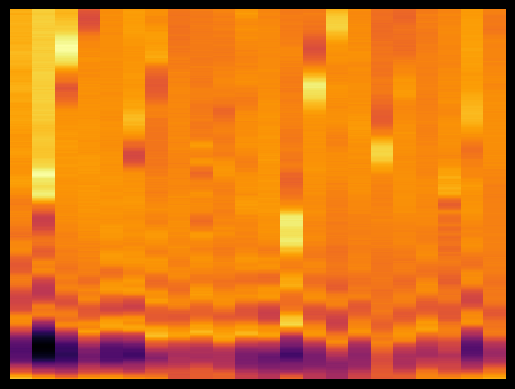

VD: 42.95 Prediction: 1 Probability: tensor(0.0003)


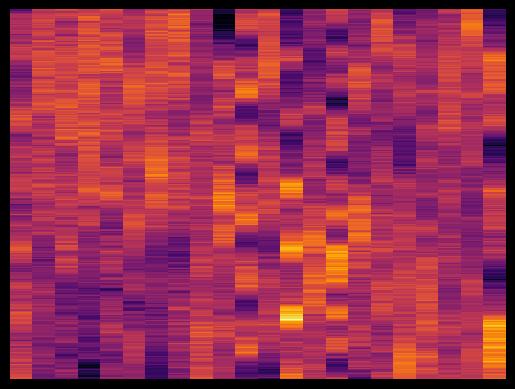

VD: 46.85000000000001 Prediction: 18 Probability: tensor(2.0254e-06)


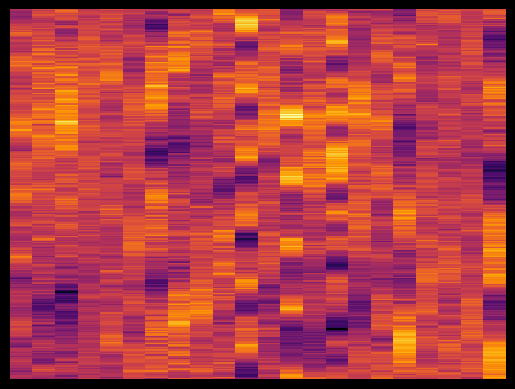

VD: 49.85000000000001 Prediction: 1 Probability: tensor(7.3941e-05)


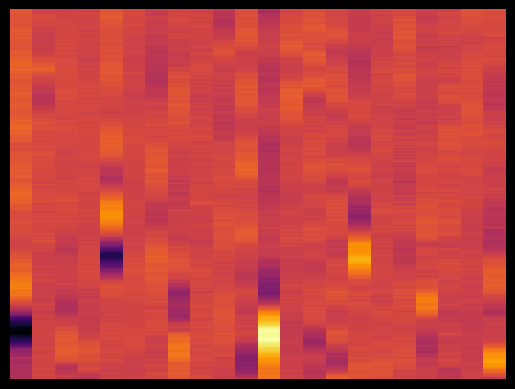

VD: 56.60000000000001 Prediction: 4 Probability: tensor(0.6514)


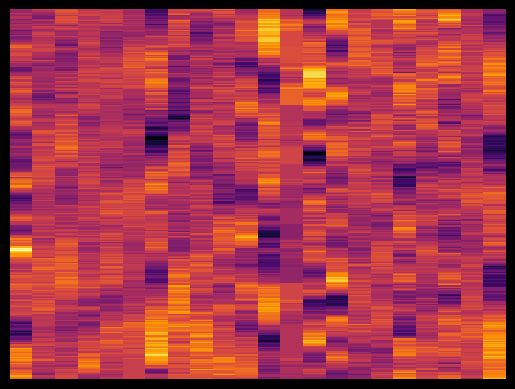

VD: 57.50000000000001 Prediction: 6 Probability: tensor(0.0004)


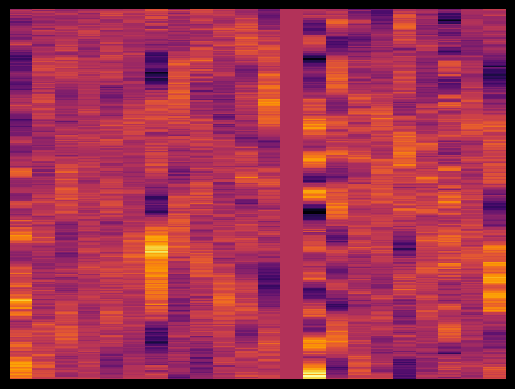

VD: 58.400000000000006 Prediction: 6 Probability: tensor(0.0584)


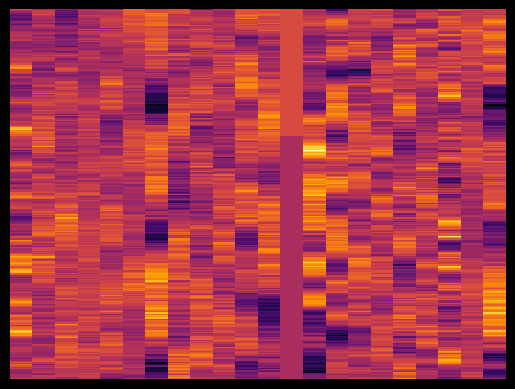

VD: 58.85000000000001 Prediction: 6 Probability: tensor(0.7707)


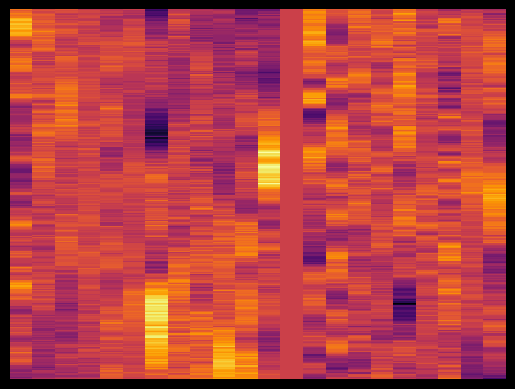

VD: 59.300000000000004 Prediction: 6 Probability: tensor(0.7073)


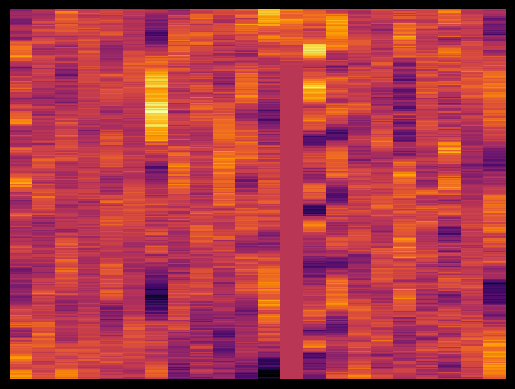

VD: 59.75000000000001 Prediction: 6 Probability: tensor(0.0596)


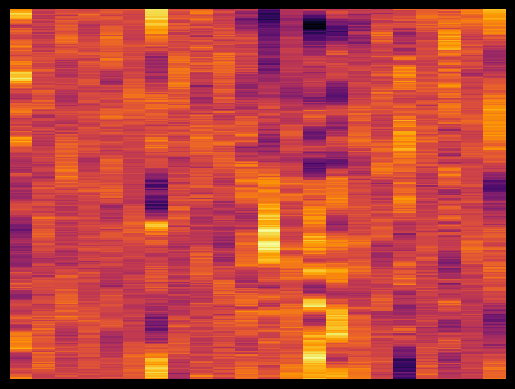

VD: 60.20000000000001 Prediction: 14 Probability: tensor(1.1070e-05)


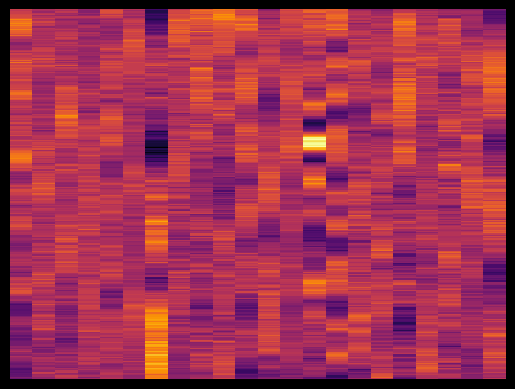

VD: 60.800000000000004 Prediction: 6 Probability: tensor(0.9792)


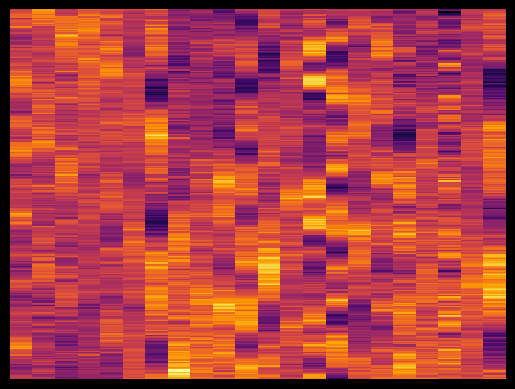

VD: 63.20000000000001 Prediction: 6 Probability: tensor(0.9994)


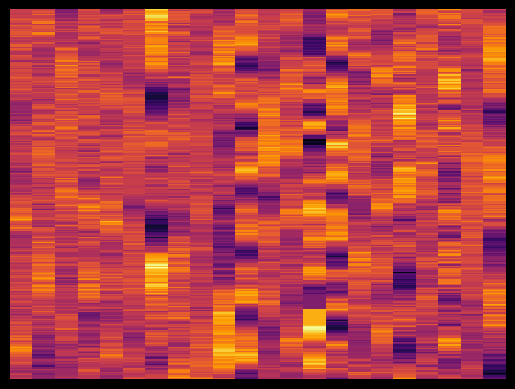

VD: 63.95000000000001 Prediction: 6 Probability: tensor(0.9902)


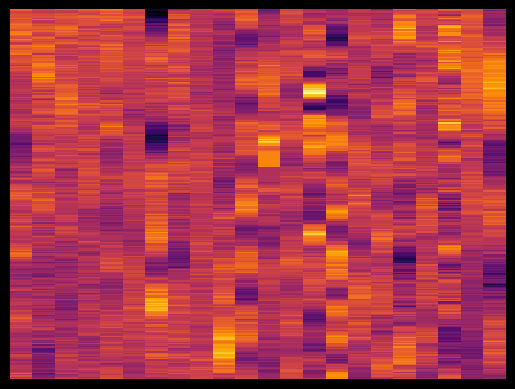

VD: 64.4 Prediction: 6 Probability: tensor(0.9610)


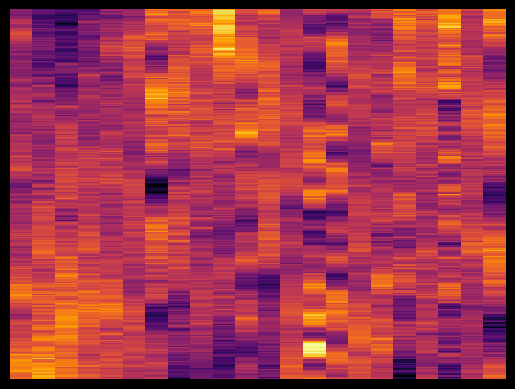

VD: 64.85 Prediction: 6 Probability: tensor(0.9827)


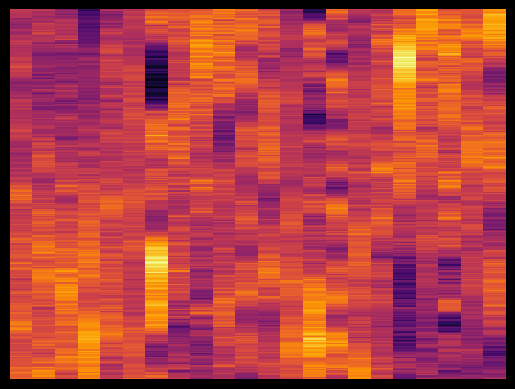

VD: 65.30000000000001 Prediction: 6 Probability: tensor(0.0022)


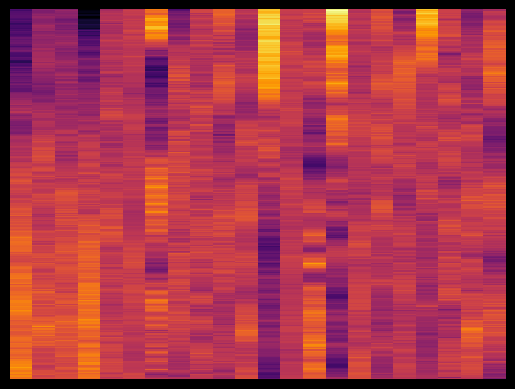

VD: 65.75 Prediction: 1 Probability: tensor(4.2208e-06)


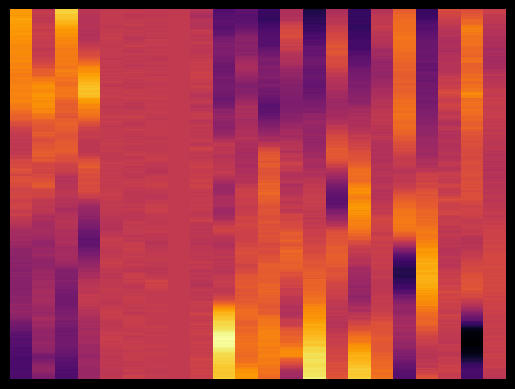

VD: 67.10000000000002 Prediction: 17 Probability: tensor(1.0553e-06)


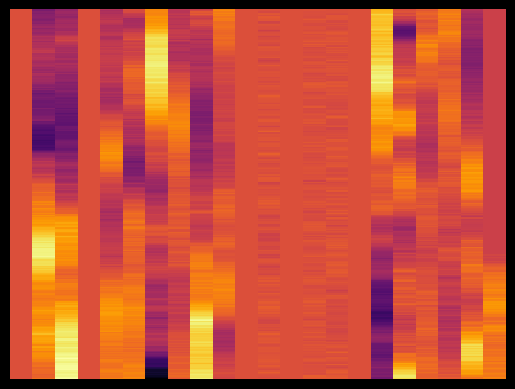

VD: 69.05000000000001 Prediction: 17 Probability: tensor(0.8384)


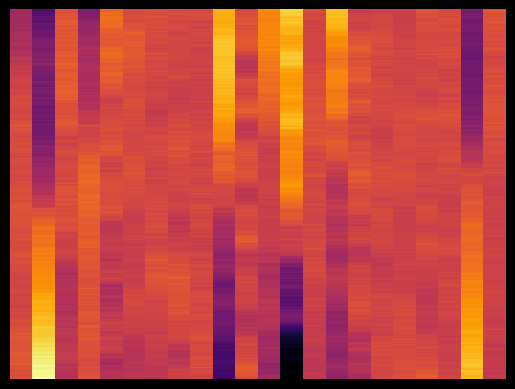

VD: 70.70000000000002 Prediction: 2 Probability: tensor(4.0206e-05)


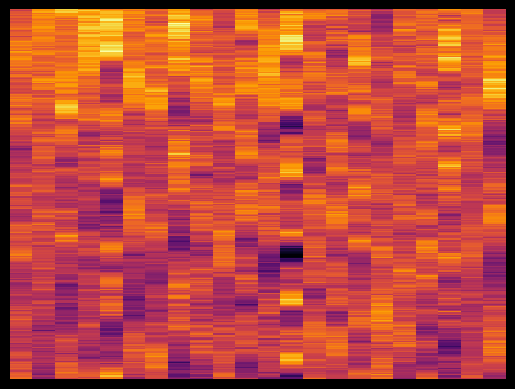

VD: 85.25 Prediction: 11 Probability: tensor(6.1587e-07)


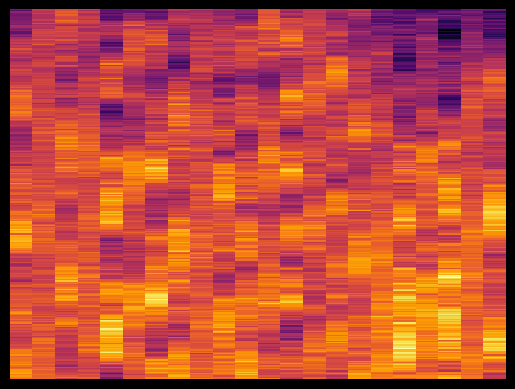

VD: 109.4 Prediction: 11 Probability: tensor(8.0538e-07)


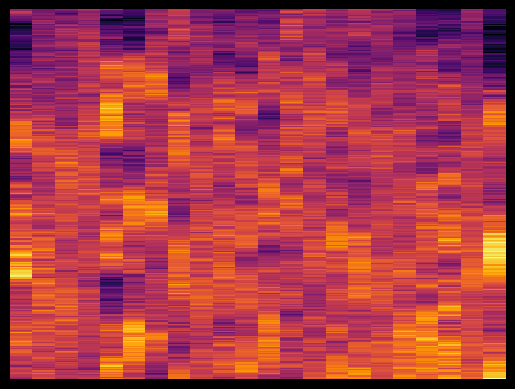

VD: 110.60000000000002 Prediction: 4 Probability: tensor(0.4993)


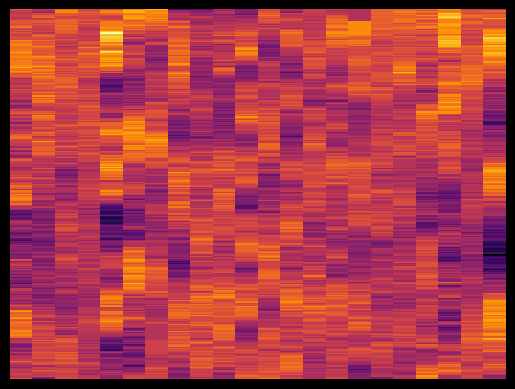

VD: 111.50000000000003 Prediction: 18 Probability: tensor(2.5748e-06)


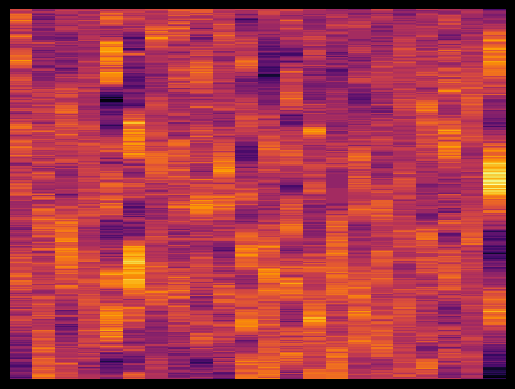

VD: 116.60000000000002 Prediction: 4 Probability: tensor(3.0230e-05)


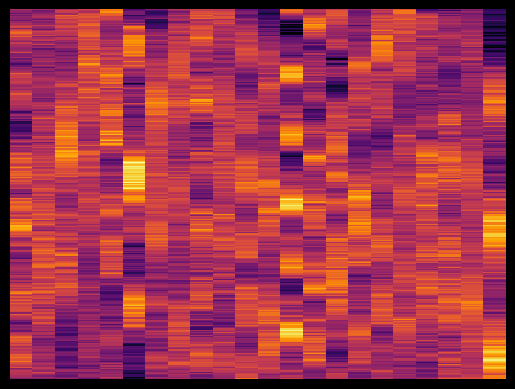

VD: 121.85000000000002 Prediction: 12 Probability: tensor(2.5974e-06)


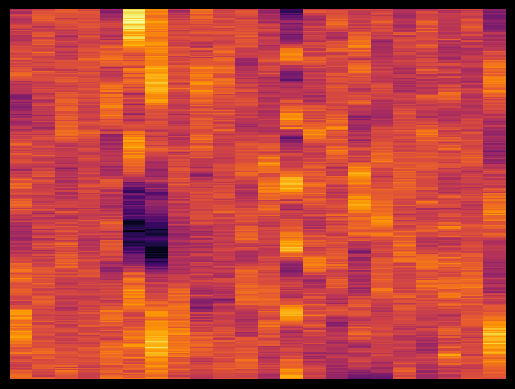

VD: 122.15 Prediction: 6 Probability: tensor(0.9993)


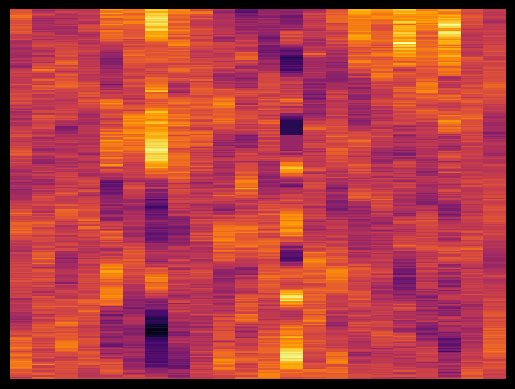

VD: 143.30000000000004 Prediction: 6 Probability: tensor(0.0003)


KeyboardInterrupt: 

In [22]:
model.to(device)
preds = argmax_probs
probs = max_probs
positive_indices = [i for i, (p, prob) in enumerate(zip(argmax_probs, max_probs)) if p != 0 and prob > 0.9]
filtered_positive_indices = filter_consecutive(positive_indices)
print(len(filtered_positive_indices), "positive indices found")
positive_VD = [((img_start + img_end) / 2) for (img_start, img_end) in np.array(ranges)[filtered_positive_indices]]
positive_probs = [probs[i] for i in filtered_positive_indices]
positive_preds = [preds[i] for i in filtered_positive_indices]
out_dir = os.path.join(root_dir, "test_21class/pos")
os.makedirs(out_dir, exist_ok=True)
model.eval()
with torch.no_grad():
    for vd in positive_VD:

        img_std = gen_image(vd, show_im=True, normalize="std")[:20, :]
        img_patch = gen_image(vd, show_im=False, normalize="patch")[:20, :]
        img_patch_trend = seasonal_decompose(img_patch.T, model='additive', period=30, extrapolate_trend=2).trend.T
        img = np.stack((img_patch, img_patch_trend, img_std), axis=0)  # shape: (3, H, W)
        img = transform(img).unsqueeze(0).to(device)
        #np.save(os.path.join(out_dir, f"img_{vd:.2f}"), img)

        model.to(device)
        model.eval()
        raw_outputs = model(img.to(device))
        pred = raw_outputs.argmax().cpu().item()
        prob = raw_outputs.sigmoid().max().cpu()
        print("VD:", vd, "Prediction:", pred, "Probability:", prob)

        #print("Predicted indices:", preds_list[vd])


